# CNN-Based Kidney Stone Detection (From Scratch) — CET313 Prototype

**Goal:** Build and evaluate a custom CNN for kidney-stone image-level detection using a public Roboflow dataset.

## Expected dataset structure (Google Drive)
```
/content/drive/MyDrive/kidneystone/
  train/<class_name>/*.jpg|png
  valid/<class_name>/*.jpg|png
  test/<class_name>/*.jpg|png
```

## What this notebook demonstrates (beyond tutorials)
- Reproducible setup (fixed random seeds)
- Dataset audit (image counting + class distribution plot + sample inspection)
- Data augmentation visual checks (incl. grayscale comparison)
- Custom CNN
- Robust evaluation (classification report, confusion matrices, per-class recall, qualitative error analysis)
- ROC–AUC guarded for single-class test sets (avoids invalid reporting)

**Note on public dataset bias:** Some Roboflow exports contain mostly stone-positive images. This notebook includes checks to avoid misleading metrics when negatives are absent.

In [1]:
import sys, platform, tensorflow as tf
print("Python:", sys.version)
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:


import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer



In [3]:
# Reproducibility: fix random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)





In [4]:
# Dataset paths
base_dir  = "/content/drive/MyDrive/Kidney Stone.v1i.folder"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

In [5]:
# Image and training hyper-parameters
IMG_SIZE   = 150
BATCH_SIZE = 32

print("Base directory:", base_dir)
print("Train directory:", train_dir)
print("Valid directory:", valid_dir)
print("Test directory :", test_dir)

Base directory: /content/drive/MyDrive/Kidney Stone.v1i.folder
Train directory: /content/drive/MyDrive/Kidney Stone.v1i.folder/train
Valid directory: /content/drive/MyDrive/Kidney Stone.v1i.folder/valid
Test directory : /content/drive/MyDrive/Kidney Stone.v1i.folder/test


In [6]:
# Helper functions and training class distribution

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def get_class_counts(path):
    """
    Scan a directory in 'ImageFolder' format.
    Returns:
      - list of class names (sorted)
      - list with number of image files in each class
    """
    classes = sorted(
        [c for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))]
    )
    counts = []
    for c in classes:
        class_path = os.path.join(path, c)
        n_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(IMAGE_EXTS)
        ])
        counts.append(n_images)
    return classes, counts



In [7]:
# Get training classes and counts
train_classes, train_counts = get_class_counts(train_dir)

print("Training classes:", train_classes)
for c, n in zip(train_classes, train_counts):
    print(f"  {c}: {n} images")

Training classes: ['Normal', 'Stone']
  Normal: 3179 images
  Stone: 863 images


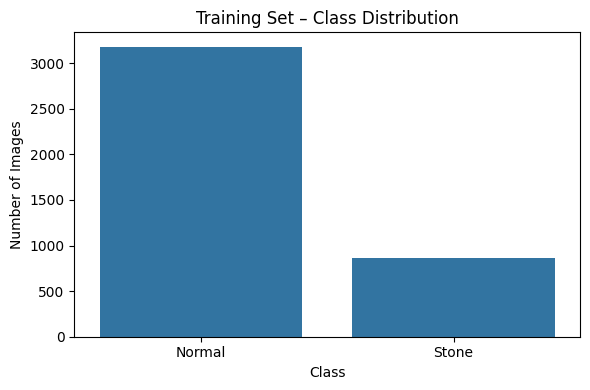

In [8]:
# Visualise class distribution in the training set
plt.figure(figsize=(6, 4))
sns.barplot(x=train_classes, y=train_counts)
plt.title("Training Set – Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

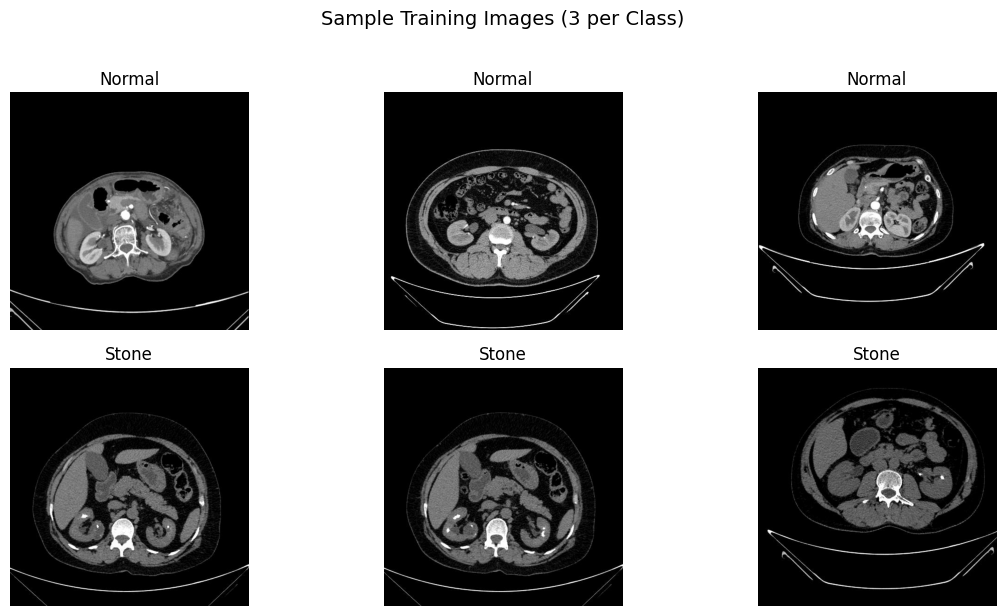

In [9]:
# Cell 3: Visual inspection – sample original images

def show_sample_images(root_dir, classes, samples_per_class=3):
    """
    Display a grid of example images from each class.
    This helps confirm dataset quality and class appearance.
    """
    plt.figure(figsize=(4 * samples_per_class, 3 * len(classes)))
    idx = 1

    for row, c in enumerate(classes):
        class_path = os.path.join(root_dir, c)
        img_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(IMAGE_EXTS)
        ]
        random.shuffle(img_files)
        img_files = img_files[:samples_per_class]

        for fname in img_files:
            img_path = os.path.join(class_path, fname)
            img = load_img(img_path)
            plt.subplot(len(classes), samples_per_class, idx)
            idx += 1
            plt.imshow(img)
            plt.title(c)
            plt.axis("off")

    plt.suptitle(f"Sample Training Images ({samples_per_class} per Class)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_sample_images(train_dir, train_classes, samples_per_class=3)


In [10]:
# Data augmentation and data generators


# For training (helps generalisation)
train_aug = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

#  Validation and test generators: only rescaling
valid_aug = ImageDataGenerator(rescale=1.0 / 255.0)
test_aug  = ImageDataGenerator(rescale=1.0 / 255.0)



In [11]:
# Build generators from directories
train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_gen = valid_aug.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_aug.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_gen.class_indices.keys())
NUM_CLASSES  = len(class_labels)

print("Class indices:", train_gen.class_indices)
print("Number of classes:", NUM_CLASSES)


Found 4042 images belonging to 2 classes.
Found 510 images belonging to 2 classes.
Found 513 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stone': 1}
Number of classes: 2


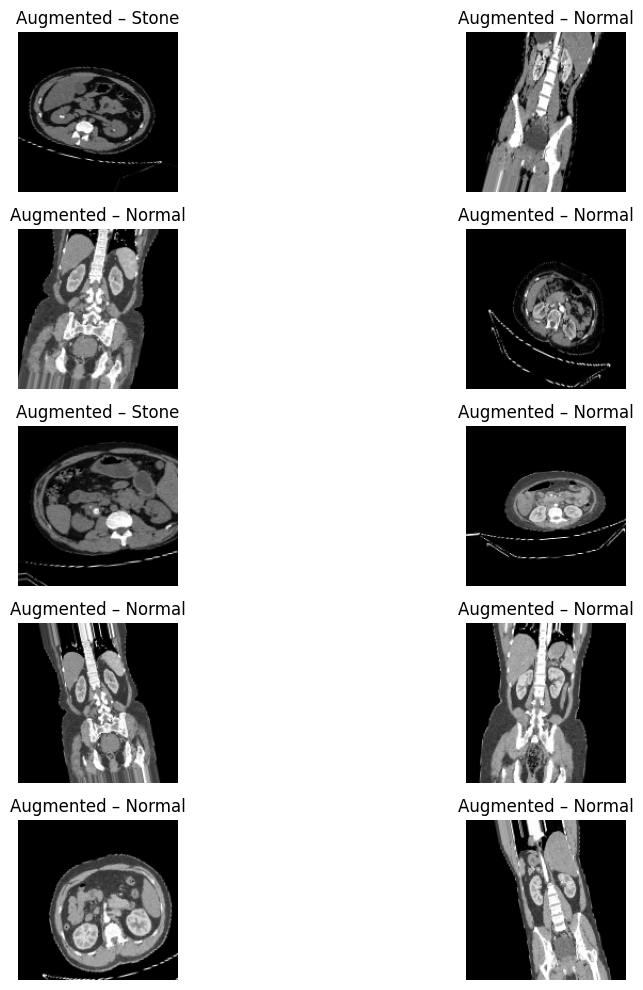

In [12]:
# Augmented images and grayscale comparison

# Grab one batch from the training generator
aug_imgs, aug_labels = next(train_gen)
aug_label_ids = np.argmax(aug_labels, axis=1)

# Show augmented images with labels
plt.figure(figsize=(12, 10))
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(aug_imgs[i])
    label_name = class_labels[aug_label_ids[i]]
    plt.title(f"Augmented – {label_name}")
    plt.axis("off")
plt.tight_layout()
plt.show()



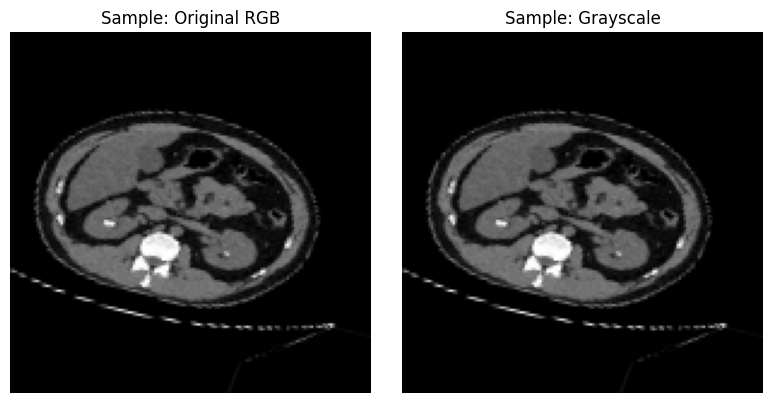

In [13]:
# Compare RGB vs Grayscale for a single example
sample_rgb  = (aug_imgs[0] * 255).astype("uint8")
sample_gray = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_rgb)
plt.title("Sample: Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_gray, cmap="gray")
plt.title("Sample: Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()


In [14]:
# Kidney stone detection CNN model (from scratch)

def build_kidney_cnn(img_size, num_classes):
    """
    Build a simple CNN for kidney stone detection.
    - Convolution + BatchNorm + MaxPooling blocks
    - Dense classification head with Dropout
    No pretrained models are used (from scratch).
    """
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same",
               input_shape=(img_size, img_size, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Classification head
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.4),
        Dense(num_classes, activation="softmax")
    ])
    return model

model = build_kidney_cnn(IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,711,746 (40.86 MB)

 Trainable params: 10,711,298 (40.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Train the model with callbacks

# Early stopping: stop if validation loss stops improving

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 20

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[reduce_lr],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1337s 10s/step - accuracy: 0.7451 - loss: 4.7876 - val_accuracy: 0.2157 - val_loss: 38.4047 - learning_rate: 0.0010
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 338ms/step - accuracy: 0.8273 - loss: 0.3648 - val_accuracy: 0.2333 - val_loss: 8.7963 - learning_rate: 0.0010
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 42s 334ms/step - accuracy: 0.8599 - loss: 0.3227 - val_accuracy: 0.4176 - val_loss: 1.1056 - learning_rate: 0.0010
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 338ms/step - accuracy: 0.8743 - loss: 0.3001 - val_accuracy: 0.4765 - val_loss: 1.3442 - learning_rate: 0.0010
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 343ms/step - accuracy: 0.8902 - loss: 0.2562 - val_accuracy: 0.9471 - val_loss: 0.1326 - learning_rate: 0.0010
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 336ms/step - accuracy: 0.8906 - loss: 0.2638 - val_accuracy: 0.9392 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 42s 334ms/step - accuracy: 0.

In [16]:
# Get final training and validation accuracy (in %)
final_train_acc = history.history["accuracy"][-1] * 100
final_val_acc   = history.history["val_accuracy"][-1] * 100

print(f"Final training accuracy:   {final_train_acc:.2f}%")
print(f"Final validation accuracy: {final_val_acc:.2f}%")


Final training accuracy:   97.62%
Final validation accuracy: 99.41%


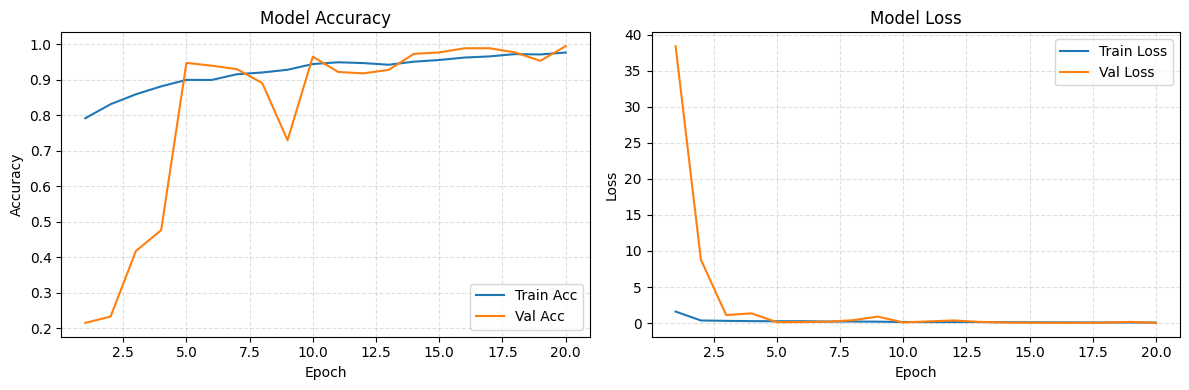

In [17]:

# Plot training and validation curves

def plot_training_history(history_obj):
    """
    Plot accuracy and loss for both training and validation sets.
    Shows whether the model is overfitting or learning properly.
    """
    acc      = history_obj.history["accuracy"]
    val_acc  = history_obj.history["val_accuracy"]
    loss     = history_obj.history["loss"]
    val_loss = history_obj.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))


    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [18]:
# Evaluate on test set – report and confusion matrix

# Reset to ensure consistent order
test_gen.reset()

# Softmax probabilities for each class
pred_proba   = model.predict(test_gen)
pred_classes = np.argmax(pred_proba, axis=1)
true_classes = test_gen.classes
filenames    = test_gen.filenames

print("True label distribution (test set):")
print(np.unique(true_classes, return_counts=True))

print("\nClassification Report (Test Set):")
print(classification_report(true_classes, pred_classes, target_names=class_labels))




17/17 ━━━━━━━━━━━━━━━━━━━━ 156s 10s/step
True label distribution (test set):
(array([0, 1], dtype=int32), array([407, 106]))

Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       407
       Stone       0.96      0.98      0.97       106

    accuracy                           0.99       513
   macro avg       0.98      0.99      0.98       513
weighted avg       0.99      0.99      0.99       513



In [19]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    output_dict=True
)

# Overall accuracy
overall_acc = report["accuracy"] * 100

# Metrics for the Stone class
stone_name = "Stone"
prec_stone  = report[stone_name]["precision"] * 100
rec_stone   = report[stone_name]["recall"]    * 100
f1_stone    = report[stone_name]["f1-score"]  * 100

print(f"Overall test accuracy: {overall_acc:.2f}%")
print(f"Precision (stone class): {prec_stone:.2f}%")
print(f"Recall (stone class):    {rec_stone:.2f}%")
print(f"F1-score (stone class):  {f1_stone:.2f}%")

Overall test accuracy: 98.83%
Precision (stone class): 96.30%
Recall (stone class):    98.11%
F1-score (stone class):  97.20%


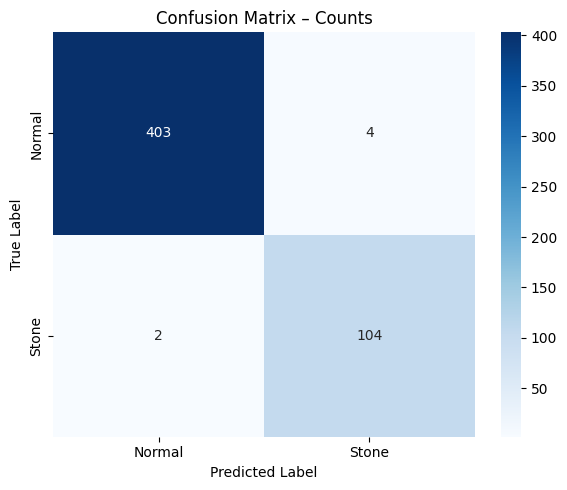

In [20]:
# Confusion matrix (counts)
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix – Counts")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

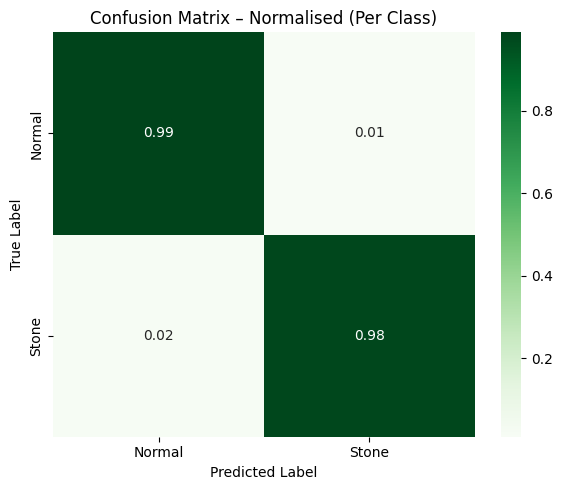

In [22]:

# Row-normalised confusion matrix (per-class accuracy)

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix – Normalised (Per Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Unique labels in test set: [0 1]


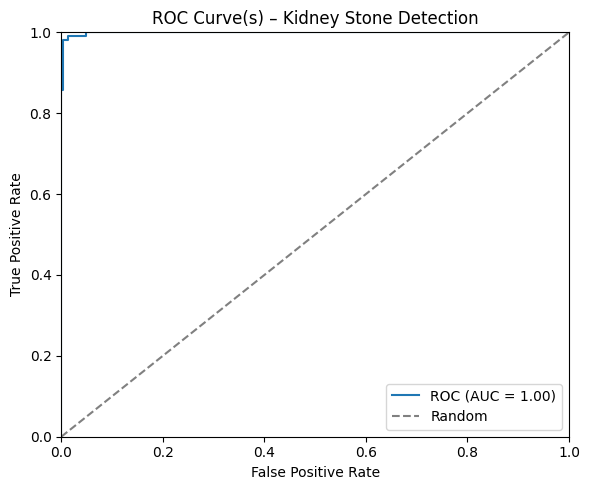

In [23]:
# ROC–AUC curves for kidney stone detection

lb = LabelBinarizer()
true_bin = lb.fit_transform(true_classes)   # shape: (n_samples, num_classes or 1)

unique_labels = np.unique(true_classes)
print("Unique labels in test set:", unique_labels)
plt.figure(figsize=(6, 5))

# ROC is not defined if we only have one class in the test set
if len(unique_labels) < 2:
    print("ROC–AUC cannot be computed: test set contains only one class.")
    plt.text(0.5, 0.5, "ROC not defined\n(single class in test set)",
             ha="center", va="center", fontsize=12)
    plt.axis("off")

else:
    # Binary case: one ROC curve for positive class (e.g., 'Stone')
    if true_bin.shape[1] == 1:
        if pred_proba.shape[1] == 2:
            y_score = pred_proba[:, 1]    # probability of class 1 (stone)
        else:
            y_score = pred_proba[:, 0]

        fpr, tpr, _ = roc_curve(true_bin.ravel(), y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.2f})")
    else:
        # Multi-class: one-vs-rest ROC for each class
        for i, class_name in enumerate(class_labels):
            fpr, tpr, _ = roc_curve(true_bin[:, i], pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
   # Random baseline
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

    plt.title("ROC Curve(s) – Kidney Stone Detection")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()



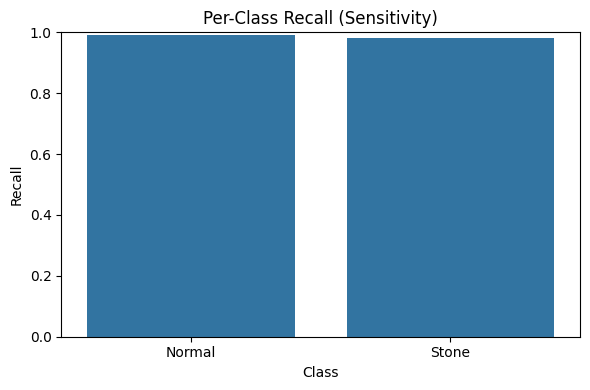

In [24]:


# Per-class recall (sensitivity – important in medical detection)

report_dict = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    output_dict=True
)

recall_per_class = [report_dict[c]["recall"] for c in class_labels]

plt.figure(figsize=(6, 4))
sns.barplot(x=class_labels, y=recall_per_class)
plt.ylim(0, 1.0)
plt.title("Per-Class Recall (Sensitivity)")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.tight_layout()
plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step
Class indices: {'Normal': 0, 'Stone': 1}
Example true/pred labels: [(np.int32(0), np.int64(0)), (np.int32(0), np.int64(0)), (np.int32(0), np.int64(0)), (np.int32(0), np.int64(0)), (np.int32(0), np.int64(0))]


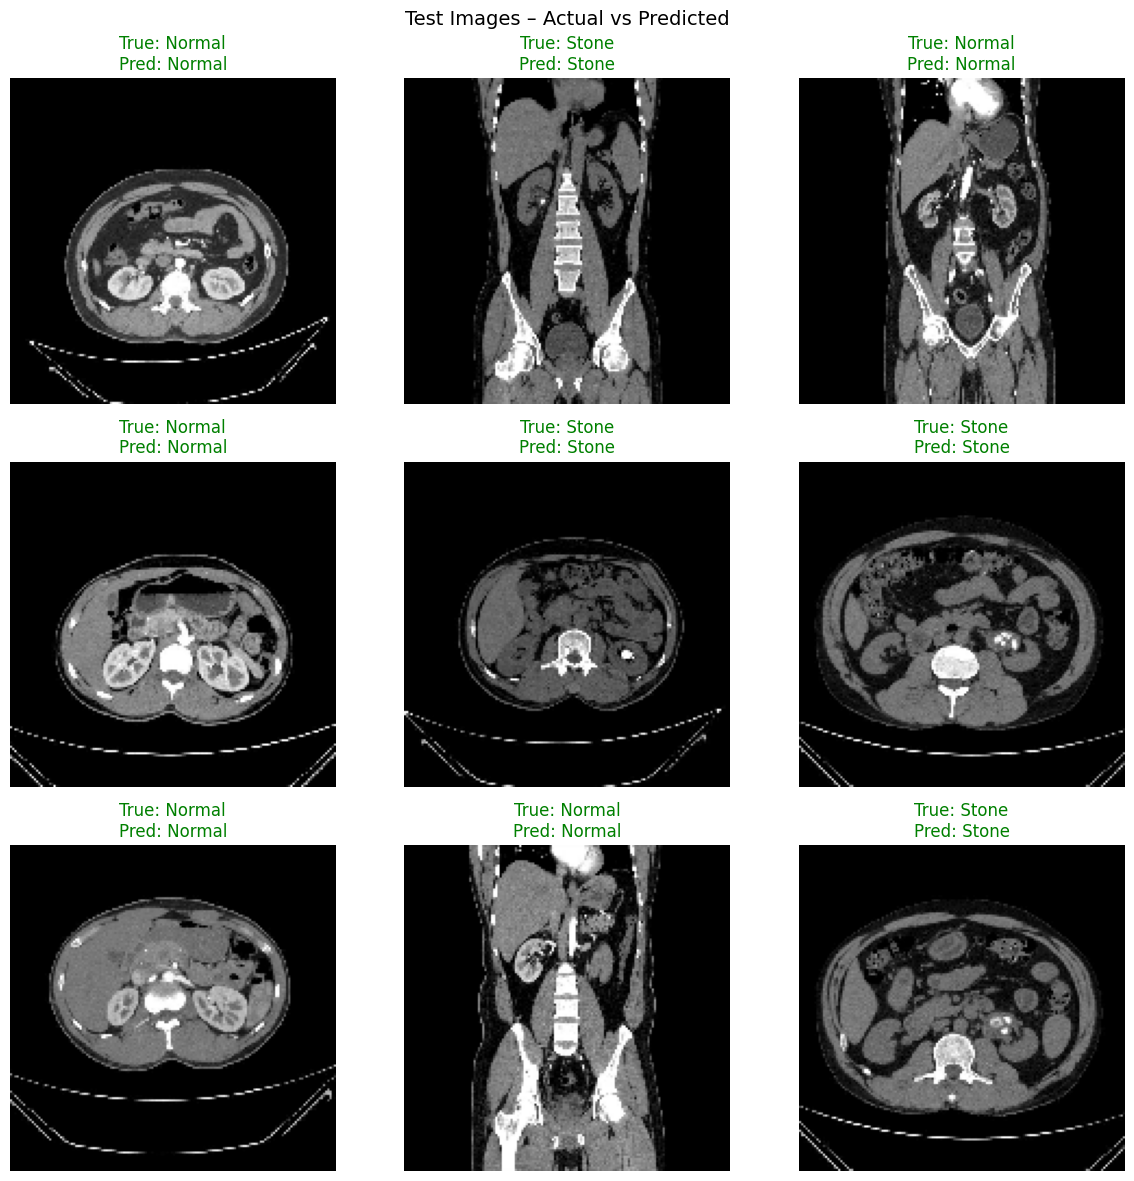

In [25]:
test_gen.reset()  # important: ensures order is consistent
pred_proba   = model.predict(test_gen)
pred_classes = np.argmax(pred_proba, axis=1)
true_classes = test_gen.classes
filenames    = test_gen.filenames

class_labels = list(test_gen.class_indices.keys())
IMG_SIZE     = test_gen.target_size[0]  # assumes square images

print("Class indices:", test_gen.class_indices)
print("Example true/pred labels:", list(zip(true_classes[:5], pred_classes[:5])))

# 2) Function to show a grid of images with True vs Predicted
def show_test_predictions(n_samples=9):
    """
    Show n_samples images from the test set with their true and predicted labels.
    Correct predictions are shown in green, incorrect in red.
    """
    total = len(filenames)
    n_samples = min(n_samples, total)

    # choosing random indices
    indices = np.arange(total)
    np.random.shuffle(indices)
    indices = indices[:n_samples]

    cols = 3
    rows = int(np.ceil(n_samples / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(indices):
        # building full path to image file on disk
        img_path = os.path.join(test_dir, filenames[idx])

        # load & preprocess image
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_arr = img_to_array(img) / 255.0

        # single-image prediction
        p = model.predict(img_arr.reshape(1, IMG_SIZE, IMG_SIZE, 3), verbose=0)
        pred_label_idx = np.argmax(p)
        pred_label     = class_labels[pred_label_idx]

        true_label_idx = true_classes[idx]
        true_label     = class_labels[true_label_idx]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_arr)
        color = "green" if pred_label_idx == true_label_idx else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis("off")

    plt.suptitle("Test Images – Actual vs Predicted", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

# 3) Call the function
show_test_predictions(n_samples=9)

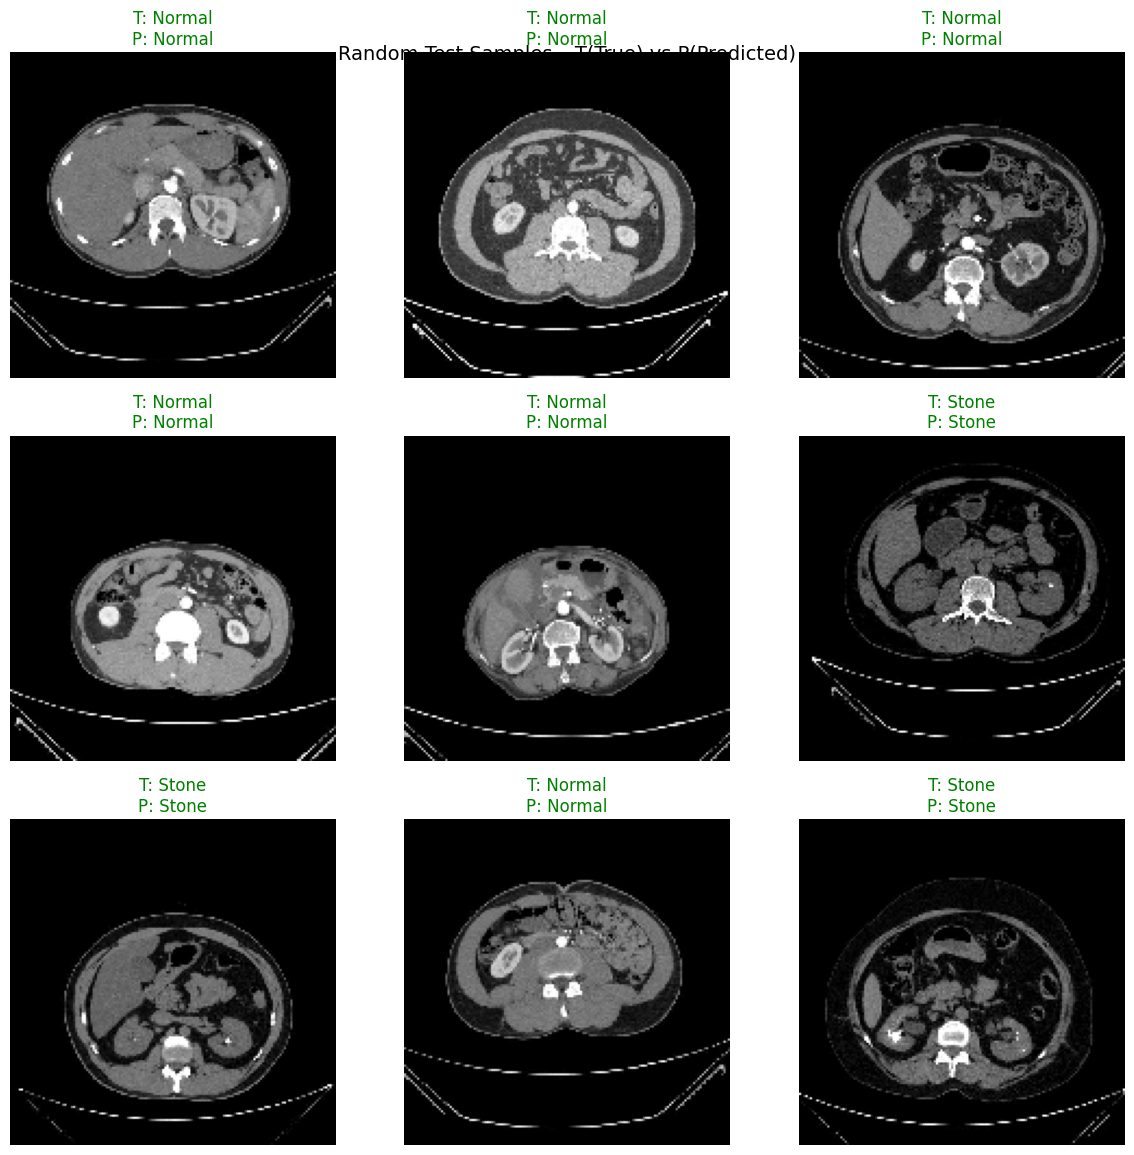

In [26]:
# Visualising predictions and misclassifications

def show_sample_predictions(n_samples=9):
    """
    Show random test images with their true and predicted labels.
    Correct predictions in green, misclassifications in red.
    """
    plt.figure(figsize=(12, 12))
    indices = np.arange(len(filenames))
    np.random.shuffle(indices)
    indices = indices[:n_samples]

    for i, idx in enumerate(indices):
        img_path = os.path.join(test_dir, filenames[idx])
        img      = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_arr  = img_to_array(img) / 255.0

        proba = model.predict(img_arr.reshape(1, IMG_SIZE, IMG_SIZE, 3), verbose=0)
        pred_label = class_labels[np.argmax(proba)]
        true_label = class_labels[true_classes[idx]]

        plt.subplot(3, 3, i + 1)
        plt.imshow(img_arr)
        color = "green" if pred_label == true_label else "red"
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
        plt.axis("off")

    plt.suptitle("Random Test Samples – T(True) vs P(Predicted)", y=0.93, fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_predictions(n_samples=9)




Number of misclassified test samples: 6


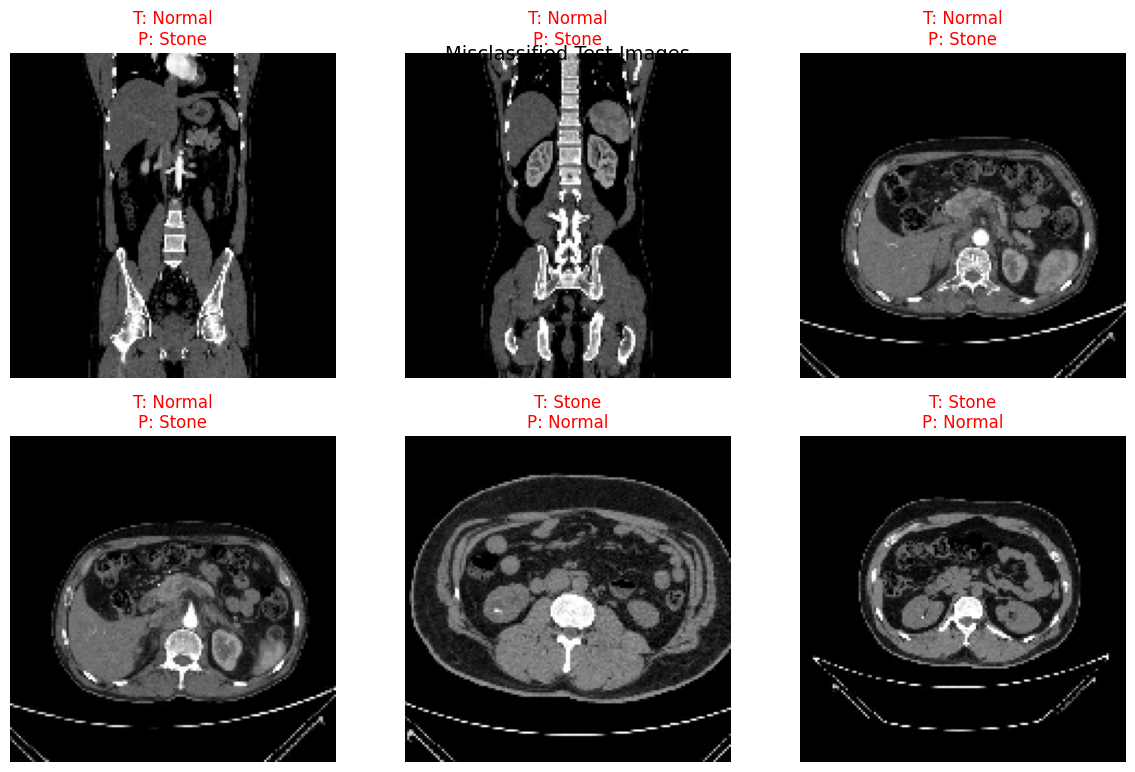

In [27]:
# if there is any Misclassified images
mis_idx = np.where(pred_classes != true_classes)[0]
print(f"Number of misclassified test samples: {len(mis_idx)}")

if len(mis_idx) > 0:
    n_show = min(9, len(mis_idx))
    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(mis_idx[:n_show]):
        img_path  = os.path.join(test_dir, filenames[idx])
        img       = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_arr   = img_to_array(img) / 255.0
        true_lab  = class_labels[true_classes[idx]]
        pred_lab  = class_labels[pred_classes[idx]]

        plt.subplot(3, 3, i + 1)
        plt.imshow(img_arr)
        plt.title(f"T: {true_lab}\nP: {pred_lab}", color="red")
        plt.axis("off")

    plt.suptitle("Misclassified Test Images", y=0.93, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples – perfect predictions on test set.")

In [28]:
print("Class indices:", test_gen.class_indices)
print("Unique labels in test set:", np.unique(test_gen.classes, return_counts=True))


Class indices: {'Normal': 0, 'Stone': 1}
Unique labels in test set: (array([0, 1], dtype=int32), array([407, 106]))


Although the Roboflow “Kidney Stone” dataset originates from an object-detection project, the version used in this prototype has been exported into a folder-based image classification structure with two classes: Normal and Stone. The split distribution is imbalanced (Train: Normal 3179, Stone 863; Valid: Normal 400, Stone 110; Test: Normal 407, Stone 106), so performance is assessed using multiple complementary metrics.

Because the held-out test set contains both classes (unique labels [0, 1]), ROC–AUC can be computed meaningfully. The notebook therefore plots the ROC curve using the model’s predicted probability score for the positive class (Stone) and reports the corresponding AUC. In this evaluation, the ROC curve achieves AUC = 0.99, indicating strong separability between Normal and Stone images on the test split. ROC–AUC is reported alongside accuracy, confusion matrix, precision, recall, and F1-score to provide a complete evaluation, with particular emphasis on recall due to the clinical risk associated with missed stones (false negatives).
